# Tunable transmon qubit (SQUID)

This notebook revisits the scqubits single-qubit `TunableTransmon` flow using the features currently available in `ScQubitsMimic.jl`.

Implemented here:
- effective Josephson energy $E_J(\Phi_{\mathrm{ext}})$
- energy spectrum vs flux
- energy levels vs `n_g` at fixed flux, plus charge-dispersion overlays across flux bias points
- charge-basis and phase-basis wavefunctions
- matrix elements and selected matrix elements vs flux
- symmetric vs asymmetric SQUID comparison
- validation against a `Circuit`-derived SQUID model


In [1]:
using ScQubitsMimic
using CairoMakie

_scqubitsmimic_example_dir = normpath(joinpath(dirname(pathof(ScQubitsMimic)), "..", "examples"))
if !isdefined(Main, :ScQubitsMimicExampleMakie)
    include(joinpath(_scqubitsmimic_example_dir, "makie_fontsetup.jl"))
end
ScQubitsMimicExampleMakie.setup_makie_font!()


"Apple SD Gothic Neo"

In [2]:
const _NOTEBOOK_QUBIT1D = Union{Transmon, TunableTransmon}

tunable_transmon_summary(t::TunableTransmon) = (
    EJmax=t.EJmax,
    EC=t.EC,
    d=t.d,
    flux=t.flux,
    ng=t.ng,
    ncut=t.ncut,
    truncated_dim=t.truncated_dim,
    EJmax_over_EC=t.EJmax / t.EC,
    EJ_eff=ej_effective(t),
    hilbertdim=hilbertdim(t),
)

const _MODE_FUNC_DICT = Dict{Symbol, Function}(
    :abs_sqr => abs2,
    :abs => abs,
    :real => real,
    :imag => imag,
)

const _NAME_REPLACEMENTS = Dict{Symbol, String}(
    :ng => "n_g",
    :ng1 => "n_g1",
    :ng2 => "n_g2",
    :EJ => "E_J",
    :EJ1 => "E_J1",
    :EJ2 => "E_J2",
    :EJ3 => "E_J3",
    :EC => "E_C",
    :EL => "E_L",
    :flux => "Φ_ext/Φ₀",
)

function _normalize_mode(mode::Union{Symbol, AbstractString})
    mode_sym = mode isa Symbol ? mode : Symbol(mode)
    haskey(_MODE_FUNC_DICT, mode_sym) || error("Unsupported mode: $(mode)")
    return mode_sym
end

function _process_which(which, max_index::Int)
    indices = if which isa Integer
        which == -1 ? collect(0:max_index - 1) : [Int(which)]
    else
        [Int(idx) for idx in which]
    end
    isempty(indices) && error("which must not be empty")
    all(0 .<= indices .< max_index) || error("which must be between 0 and $(max_index - 1)")
    return indices
end

_recast_name(param_name::Symbol) = get(_NAME_REPLACEMENTS, param_name, string(param_name))
_recast_name(param_name::AbstractString) = _recast_name(Symbol(param_name))

function _charge_ylabel(mode::Symbol)
    mode == :abs_sqr && return "|ψ_j(n)|²"
    mode == :abs && return "|ψ_j(n)|"
    mode == :real && return "Re ψ_j(n)"
    return "Im ψ_j(n)"
end

function _phase_ylabel(mode::Symbol)
    mode == :abs_sqr && return "|ψ_j(φ)|², energy [GHz]"
    mode == :abs && return "|ψ_j(φ)|, energy [GHz]"
    mode == :real && return "Re ψ_j(φ), energy [GHz]"
    return "Im ψ_j(φ), energy [GHz]"
end

function _phi_values(; phi_grid=nothing, phi_range=(-π, π), pt_count::Int=151)
    if phi_grid !== nothing
        return collect(phi_grid)
    end
    φrange = collect(phi_range)
    if length(φrange) == 2
        return collect(range(φrange[1], φrange[2], length=pt_count))
    elseif length(φrange) == 3
        return collect(range(φrange[1], φrange[2], length=Int(φrange[3])))
    end
    error("phi_range must have length 2 or 3")
end

function _resolve_esys(sys::_NOTEBOOK_QUBIT1D, esys, states0::AbstractVector{<:Integer})
    required = max(maximum(states0) + 1, 3)
    if esys === nothing
        return eigensys(sys; evals_count=required)
    end
    evals, evecs = esys
    length(evals) >= required || error("esys must contain at least $(required) eigenstates")
    return evals, evecs
end

function _standardize_sign(amplitudes::AbstractVector)
    halfway = length(amplitudes) ÷ 2
    halfway == 0 && return collect(amplitudes)
    sign_factor = sign(sum(amplitudes[1:halfway]))
    return iszero(sign_factor) ? collect(amplitudes) : sign_factor .* amplitudes
end

function _set_wavefunction_scaling(wavefunctions, potential_vals)
    Y_RANGE_THRESHOLD_FRACTION = 1 / 12
    FILLING_FRACTION = 0.9
    MAX_AMPLITUDE_FRACTION = 1 / 7
    PRECISION_THRESHOLD = 1e-6

    energies = [wf.energy for wf in wavefunctions]
    e_max = maximum(energies)
    e_min = minimum(energies)
    e_range = e_max - e_min
    y_min = minimum(potential_vals)
    y_max = e_max + 0.3 * e_range
    y_range = y_max - y_min

    amp_mins = [minimum(wf.amplitudes) for wf in wavefunctions]
    amp_maxs = [maximum(wf.amplitudes) for wf in wavefunctions]
    max_amplitude_range = maximum(amp_maxs .- amp_mins)

    max_amplitude_range < PRECISION_THRESHOLD && return 1.0

    scale_factor = y_range * MAX_AMPLITUDE_FRACTION / max_amplitude_range
    amp_mins .*= scale_factor
    amp_maxs .*= scale_factor

    length(wavefunctions) == 1 && return scale_factor

    amplitude_fillings = [abs(amp_maxs[i]) + abs(amp_mins[i + 1]) for i in 1:length(wavefunctions)-1]
    energy_spacings = [energies[i + 1] - energies[i] for i in 1:length(wavefunctions)-1]

    for idx in eachindex(energy_spacings)
        energy_gap = energy_spacings[idx]
        amplitude_filling = amplitude_fillings[idx]
        if energy_gap > y_range * Y_RANGE_THRESHOLD_FRACTION &&
           amplitude_filling > energy_gap * FILLING_FRACTION
            reduction = energy_gap * FILLING_FRACTION / amplitude_filling
            scale_factor *= reduction
            amp_mins .*= reduction
            amp_maxs .*= reduction
            amplitude_fillings .*= reduction
        end
    end

    return scale_factor
end

_phase_potential(sys::Transmon, phis) = -sys.EJ .* cos.(phis)
_phase_potential(sys::TunableTransmon, phis) = -ej_effective(sys) .* cos.(phis)

function numberbasis_wavefunction_data(sys::_NOTEBOOK_QUBIT1D; esys=nothing, which::Int=0)
    states0 = _process_which(which, sys.truncated_dim)
    evals, evecs = _resolve_esys(sys, esys, states0)
    state0 = only(states0)
    state = state0 + 1
    return (
        basis_labels=collect(-sys.ncut:sys.ncut),
        amplitudes=evecs[:, state],
        energy=evals[state],
    )
end

function phase_wavefunction_data(sys::_NOTEBOOK_QUBIT1D, which::Int;
                                 esys=nothing,
                                 phi_grid=nothing,
                                 phi_range=(-π, π),
                                 pt_count::Int=151)
    states0 = _process_which(which, sys.truncated_dim)
    evals, evecs = _resolve_esys(sys, esys, states0)
    state0 = only(states0)
    state = state0 + 1
    charges = collect(-sys.ncut:sys.ncut)
    phis = _phi_values(phi_grid=phi_grid, phi_range=phi_range, pt_count=pt_count)
    coeffs = evecs[:, state]
    phase_factor = (1im)^state0 / sqrt(2π)
    psi_phi = ComplexF64[
        phase_factor * sum(coeffs .* exp.(1im .* ϕ .* charges))
        for ϕ in phis
    ]
    return (
        basis_labels=phis,
        amplitudes=psi_phi,
        energy=evals[state],
    )
end

function plot_n_wavefunction(sys::_NOTEBOOK_QUBIT1D, which::Int=0;
                             esys=nothing,
                             mode::Union{Symbol, AbstractString}=:real,
                             nrange=(-5, 6))
    mode_sym = _normalize_mode(mode)
    n_wavefunc = numberbasis_wavefunction_data(sys; esys=esys, which=which)
    y_vals = _MODE_FUNC_DICT[mode_sym].(n_wavefunc.amplitudes)

    fig = Figure(size=(680, 380))
    ax = Axis(fig[1, 1],
              xlabel="n",
              ylabel=_charge_ylabel(mode_sym))
    barplot!(ax, n_wavefunc.basis_labels, y_vals;
             width=0.75,
             color=:steelblue,
             strokewidth=0)
    ax.xticks = (n_wavefunc.basis_labels, string.(n_wavefunc.basis_labels))
    xlims!(ax, nrange...)
    return fig
end

plot_n_wavefunction(sys::_NOTEBOOK_QUBIT1D; which::Int=0, kwargs...) = plot_n_wavefunction(sys, which; kwargs...)

function plot_evals_vs_paramvals_scqubits(sweep::SingleSystemSweep;
                                          subtract_ground::Bool=false,
                                          evals_count::Union{Nothing, Int}=nothing)
    pvals = sweep.param_vals
    evals = copy(sweep.spectrum.eigenvalues)
    n_evals = isnothing(evals_count) ? size(evals, 2) : min(evals_count, size(evals, 2))

    if subtract_ground
        evals .-= evals[:, 1]
    end

    fig = Figure(size=(680, 380))
    ax = Axis(fig[1, 1],
              xlabel=_recast_name(sweep.param_name),
              ylabel="energy [GHz]")

    for level in 1:n_evals
        lines!(ax, pvals, evals[:, level])
    end
    return fig
end

function plot_wavefunction(sys::_NOTEBOOK_QUBIT1D,
                           which::Union{Int, Tuple, AbstractVector{<:Integer}}=0;
                           mode::Union{Symbol, AbstractString}=:real,
                           esys=nothing,
                           phi_grid=nothing,
                           phi_range=(-π, π),
                           pt_count::Int=151,
                           scaling=nothing,
                           subtract_ground::Bool=false)
    mode_sym = _normalize_mode(mode)
    states0 = _process_which(which, sys.truncated_dim)
    evals, evecs = _resolve_esys(sys, esys, states0)
    phis = _phi_values(phi_grid=phi_grid, phi_range=phi_range, pt_count=pt_count)
    potential_vals = _phase_potential(sys, phis)
    ground_energy = subtract_ground ? evals[1] : 0.0

    wavefunctions = []
    for state0 in states0
        wf = phase_wavefunction_data(sys, state0; esys=(evals, evecs), phi_grid=phis)
        amplitudes = _MODE_FUNC_DICT[mode_sym].(_standardize_sign(wf.amplitudes))
        push!(wavefunctions,
              (basis_labels=wf.basis_labels,
               amplitudes=Float64.(amplitudes),
               energy=wf.energy - ground_energy))
    end

    potential_shifted = potential_vals .- ground_energy
    scale_factor = isnothing(scaling) ? _set_wavefunction_scaling(wavefunctions, potential_shifted) : Float64(scaling)

    fig = Figure(size=(700, 420))
    ax = Axis(fig[1, 1],
              xlabel="φ",
              ylabel=_phase_ylabel(mode_sym))

    lines!(ax, phis, potential_shifted; color=:gray60, linewidth=2)

    palette = [:dodgerblue, :tomato, :darkgreen, :darkorange, :mediumpurple]
    for (idx, wf) in enumerate(wavefunctions)
        color = palette[1 + mod(idx - 1, length(palette))]
        y_vals = wf.energy .+ scale_factor .* wf.amplitudes
        baseline = fill(wf.energy, length(phis))
        band!(ax, phis, baseline, y_vals; color=(color, 0.22))
        lines!(ax, phis, y_vals; color=color, linewidth=2)
    end

    y_min = minimum(potential_shifted)
    y_max = maximum(wf.energy for wf in wavefunctions)
    y_range = y_max - y_min
    y_max += 0.3 * y_range
    y_min -= 0.1 * y_range
    ylims!(ax, y_min, y_max)
    return fig
end

function plot_phi_wavefunction(sys::_NOTEBOOK_QUBIT1D, which::Union{Int, Tuple, AbstractVector{<:Integer}}=0; kwargs...)
    return plot_wavefunction(sys, which; kwargs...)
end

function plot_phase_wavefunctions(sys::_NOTEBOOK_QUBIT1D, which::Union{Int, Tuple, AbstractVector{<:Integer}}=0; kwargs...)
    return plot_phi_wavefunction(sys, which; kwargs...)
end

plot_wavefunction(sys::_NOTEBOOK_QUBIT1D; which=0, kwargs...) = plot_wavefunction(sys, which; kwargs...)
plot_phi_wavefunction(sys::_NOTEBOOK_QUBIT1D; which=0, kwargs...) = plot_phi_wavefunction(sys, which; kwargs...)
plot_phase_wavefunctions(sys::_NOTEBOOK_QUBIT1D; which=0, kwargs...) = plot_phase_wavefunctions(sys, which; kwargs...)

function plot_charge_dispersion_overlay(configs;
                                        ng_vals=range(-2.0, 2.0, length=220),
                                        evals_count::Int=6,
                                        subtract_ground::Bool=true)
    fig = Figure(size=(760, 420))
    ax = Axis(fig[1, 1],
              xlabel=_recast_name(:ng),
              ylabel="energy [GHz]")
    colors = [:dodgerblue, :tomato, :darkgreen, :mediumpurple]

    for (cfg_idx, (label, sys, linestyle)) in enumerate(configs)
        sweep = get_spectrum_vs_paramvals(sys, :ng, collect(ng_vals); evals_count=evals_count)
        vals = subtract_ground ? (sweep.eigenvalues .- sweep.eigenvalues[:, 1]) : sweep.eigenvalues
        color = colors[1 + mod(cfg_idx - 1, length(colors))]
        for level in 1:evals_count
            lines!(ax, sweep.param_vals, vals[:, level],
                   color=color,
                   linestyle=linestyle,
                   linewidth=level <= 2 ? 2.5 : 1.5,
                   alpha=0.85)
        end
        lines!(ax, [NaN], [NaN], color=color, linestyle=linestyle, linewidth=2.5, label=label)
    end

    axislegend(ax, position=:rb)
    return fig
end

function plot_matelems_vs_paramvals(sys::ScQubitsMimic.AbstractQuantumSystem,
                                    op_builder::Function,
                                    param_name::Symbol,
                                    param_vals;
                                    pairs=[(1, 2), (1, 3), (2, 3), (1, 4)],
                                    mode::Union{Symbol, AbstractString}=:abs)
    mode_sym = _normalize_mode(mode)
    original = get_param(sys, param_name)
    max_eval = maximum(collect(Iterators.flatten(pairs)))
    traces = Dict{Tuple{Int, Int}, Vector{Float64}}(pair => Float64[] for pair in pairs)

    for val in param_vals
        set_param!(sys, param_name, Float64(val))
        op = op_builder(sys)
        table = matrixelement_table(sys, op; evals_count=max_eval)
        for pair in pairs
            i, j = pair
            elem = table[i, j]
            value = _MODE_FUNC_DICT[mode_sym](elem)
            push!(traces[pair], Float64(value))
        end
    end

    set_param!(sys, param_name, original)

    fig = Figure(size=(760, 420))
    ax = Axis(fig[1, 1],
              xlabel=_recast_name(param_name),
              ylabel="matrix element")
    for pair in pairs
        i, j = pair
        lines!(ax, collect(param_vals), traces[pair], label="$(i-1),$(j-1)")
    end
    axislegend(ax, position=:rt)
    return fig
end


plot_matelems_vs_paramvals (generic function with 1 method)

## 1. SQUID-based transmon Hamiltonian

In a SQUID loop formed by two Josephson junctions ($E_{J1}$, $E_{J2}$), the external flux $\Phi_{\mathrm{ext}}$ tunes the effective Josephson energy:

$$E_J(\Phi_{\mathrm{ext}}) = E_{J,\max} \left|\cos\left(\pi\frac{\Phi_{\mathrm{ext}}}{\Phi_0}\right)\right| \sqrt{1 + d^2 \tan^2\left(\pi\frac{\Phi_{\mathrm{ext}}}{\Phi_0}\right)}$$

where:
- $E_{J,\max} = E_{J1} + E_{J2}$ is the maximum Josephson energy
- $d = (E_{J2} - E_{J1})/(E_{J1} + E_{J2})$ is the junction asymmetry
- $\Phi_0 = h/(2e)$ is the flux quantum

For a symmetric SQUID ($d=0$), $E_J$ vanishes at half a flux quantum ($\Phi_{\mathrm{ext}} = \Phi_0/2$).


In [22]:
2/7

0.2857142857142857

In [65]:
tmon = TunableTransmon(EJmax=15.0, EC=0.2, d=0.4, flux=0.0, ng=0.0, ncut=30, truncated_dim=12)
tunable_transmon_summary(tmon)

ccoupler = TunableTransmon(EJmax=50.0, EC=0.2, d=0.1, flux=0.0, ng=0.0, ncut=30, truncated_dim=12)

TunableTransmon(50.0, 0.2, 0.1, 0.0, 0.0, 30, 12)

## 2. Effective Josephson energy vs external flux

We sweep the external flux and evaluate how the effective $E_J$ changes across the SQUID tuning curve.


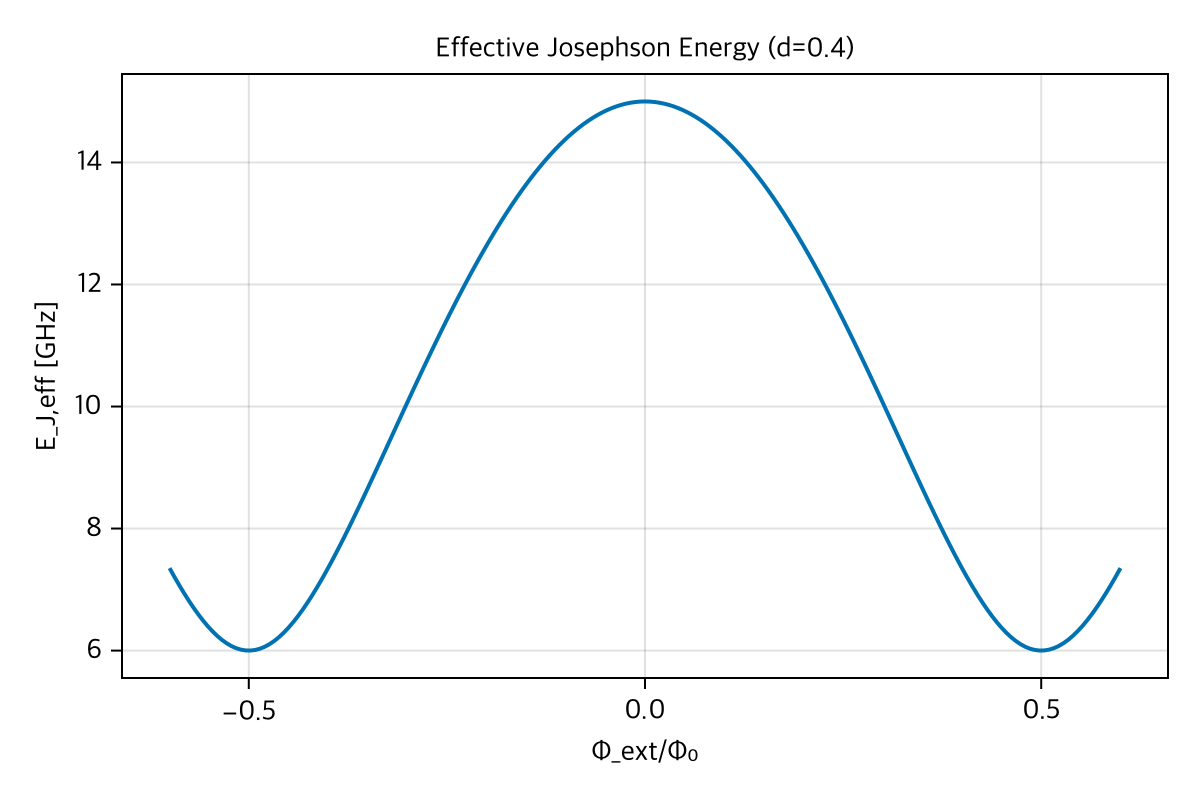

In [66]:
tmon_flux_curve = deepcopy(tmon)
fluxes = range(-0.6, 0.6, length=201)
ej_vals = Float64[]
for f in fluxes
    tmon_flux_curve.flux = f
    push!(ej_vals, ej_effective(tmon_flux_curve))
end

fig = Figure(size=(600, 400))
ax = Axis(fig[1, 1],
    xlabel=_recast_name(:flux),
    ylabel="E_J,eff [GHz]",
    title="Effective Josephson Energy (d=$(tmon.d))")
lines!(ax, collect(fluxes), ej_vals, linewidth=2)
fig


## 3. Energy spectrum vs external flux

This section is the notebook equivalent of the scqubits call `tune_tmon.plot_evals_vs_paramvals('flux', flux_list, subtract_ground=True)`. We sweep `flux`, subtract the ground-state energy at each point, and inspect how the excited levels move across the SQUID tuning curve. The transition frequencies are largest at $\Phi_{\mathrm{ext}} = 0$ and smallest near $\Phi_{\mathrm{ext}} = \Phi_0/2$.


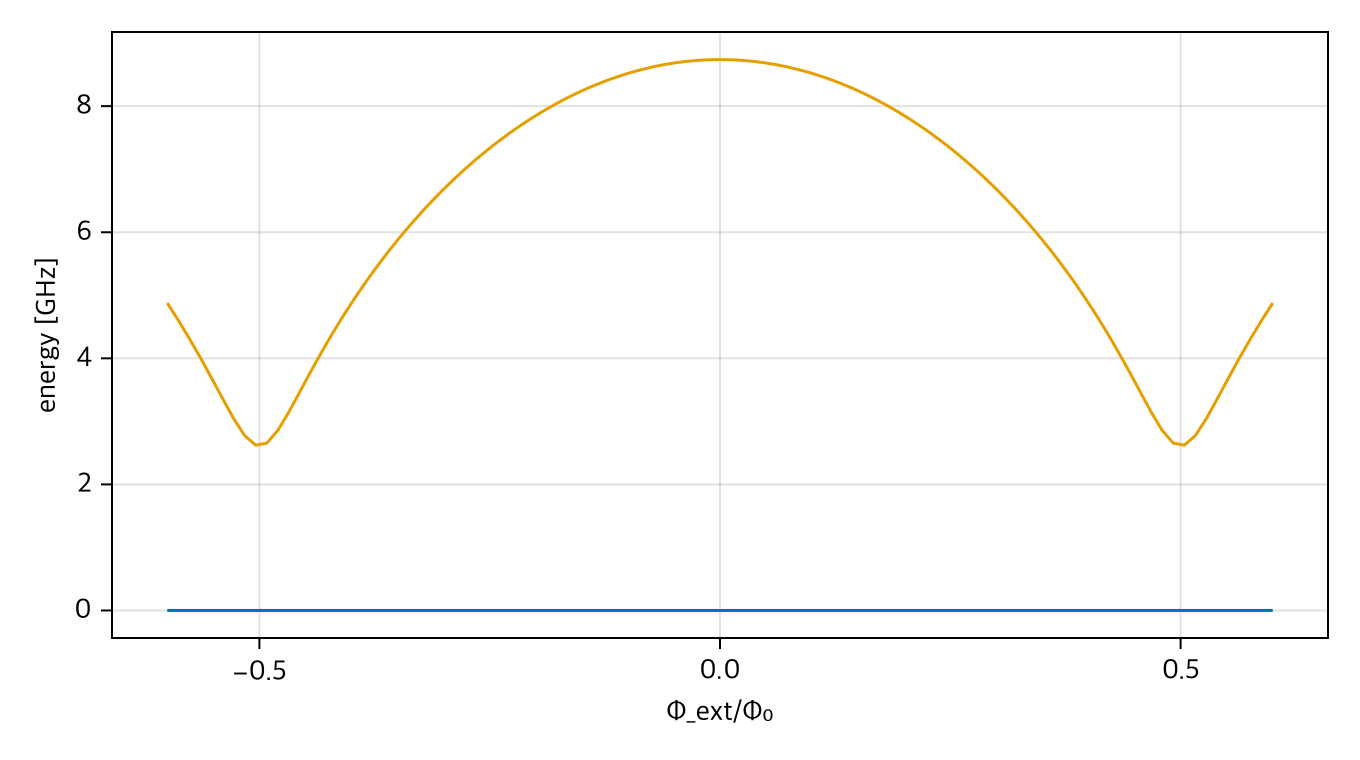

In [67]:
tmon_flux_spec = deepcopy(ccoupler)
sweep = SingleSystemSweep(tmon_flux_spec, :flux, range(-0.6, 0.6, length=101); evals_count=6)
plot_evals_vs_paramvals_scqubits(sweep; subtract_ground=true, evals_count=2)


In [58]:
tmon_probe = deepcopy(tmon)
println("  Φ/Φ₀      ω₀₁ (GHz)    α (GHz)")
println("  " * "-"^35)
for flux in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
    tmon_probe.flux = flux
    e = eigenvals(tmon_probe; evals_count=3)
    w01 = e[2] - e[1]
    w12 = e[3] - e[2]
    α = w12 - w01
    println("  $(round(flux, digits=2))       $(round(w01, digits=4))      $(round(α, digits=4))")
end


  Φ/Φ₀      ω₀₁ (GHz)    α (GHz)
  -----------------------------------
  0.0       4.6898      -0.2228
  0.1       4.5882      -0.2234
  0.2       4.2865      -0.2255
  0.3       3.8013      -0.2297
  0.4       3.2158      -0.2381
  0.5       2.8827      -0.2473


## 4. Symmetric vs asymmetric SQUID

The junction asymmetry $d$ strongly affects the behavior near the frustration point ($\Phi_{\mathrm{ext}} = \Phi_0/2$):

- **Symmetric SQUID** ($d = 0$): $E_J(\Phi_0/2) = 0$ so the qubit frequency collapses toward zero.
- **Asymmetric SQUID** ($d \neq 0$): $E_J(\Phi_0/2) = E_{J,\max} \cdot d$ so a finite residual frequency remains.

An asymmetric SQUID therefore keeps a sweet spot near the frustration point while avoiding complete gap closure.


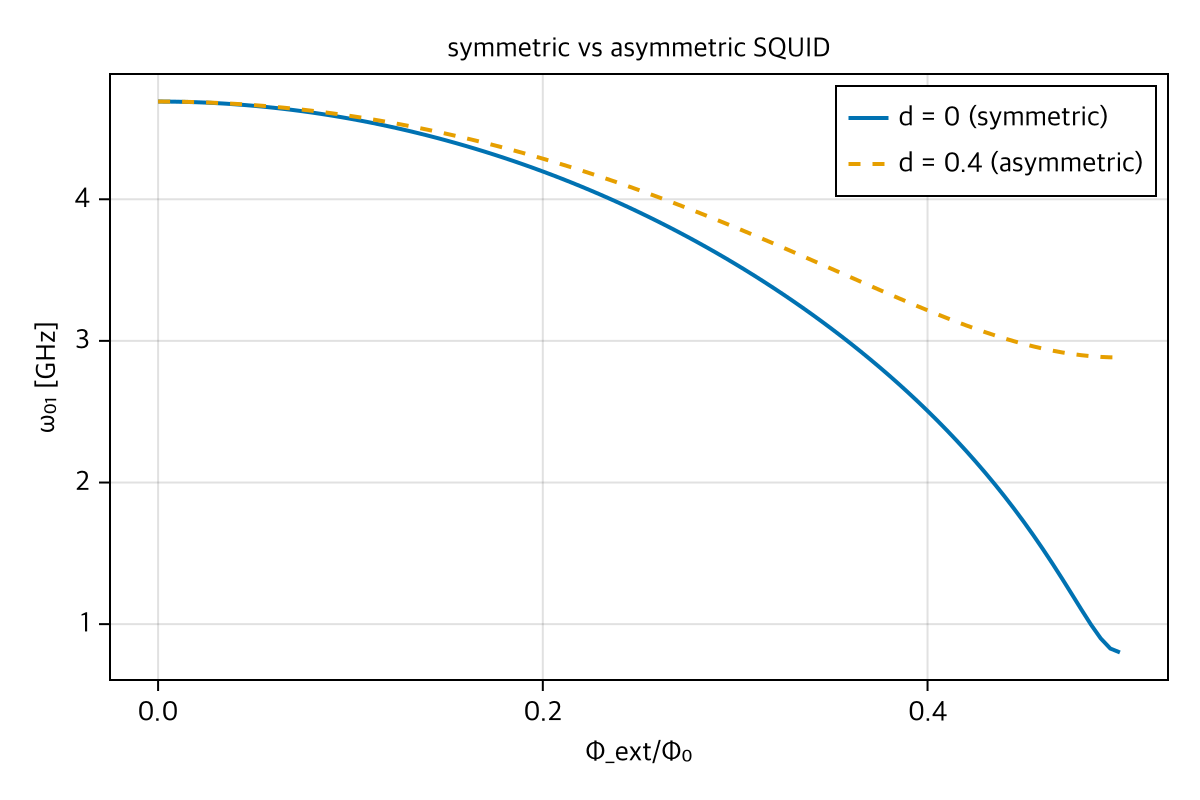

In [7]:
tmon_sym = TunableTransmon(EJmax=15.0, EC=0.2, d=0.0, flux=0.0, ncut=30, truncated_dim=4) # EC is EC_total, not per-junction EC_branch
tmon_asym = TunableTransmon(EJmax=15.0, EC=0.2, d=0.4, flux=0.0, ncut=30, truncated_dim=4) 

flux_range = range(0.0, 0.5, length=101)
w01_sym = Float64[]
w01_asym = Float64[]

for f in flux_range
    tmon_sym.flux = f
    tmon_asym.flux = f
    e_s = eigenvals(tmon_sym; evals_count=2)
    e_a = eigenvals(tmon_asym; evals_count=2)
    push!(w01_sym, e_s[2] - e_s[1])
    push!(w01_asym, e_a[2] - e_a[1])
end

fig = Figure(size=(600, 400))
ax = Axis(fig[1, 1],
    xlabel=_recast_name(:flux),
    ylabel="ω₀₁ [GHz]",
    title="symmetric vs asymmetric SQUID")
lines!(ax, collect(flux_range), w01_sym, label="d = 0 (symmetric)", linewidth=2)
lines!(ax, collect(flux_range), w01_asym, label="d = 0.4 (asymmetric)", linewidth=2, linestyle=:dash)
axislegend(ax)
fig


In [8]:
# Comparison at the frustration point
tmon_sym.flux = 0.5
tmon_asym.flux = 0.5

println("Φ/Φ₀ = 0.5 (frustration point):")
println("  symmetric:   EJ_eff = $(round(ej_effective(tmon_sym), digits=6)) GHz")
println("  asymmetric: EJ_eff = $(round(ej_effective(tmon_asym), digits=6)) GHz")

e_sym = eigenvals(tmon_sym; evals_count=2)
e_asym = eigenvals(tmon_asym; evals_count=2)
println("  symmetric:   ω₀₁ = $(round(e_sym[2] - e_sym[1], digits=4)) GHz")
println("  asymmetric: ω₀₁ = $(round(e_asym[2] - e_asym[1], digits=4)) GHz")


Φ/Φ₀ = 0.5 (frustration point):
  symmetric:   EJ_eff = 0.0 GHz
  asymmetric: EJ_eff = 6.0 GHz
  symmetric:   ω₀₁ = 0.8 GHz
  asymmetric: ω₀₁ = 2.8827 GHz


## 5. Energy levels vs `n_g` at fixed flux

Following the single-qubit `TunableTransmon` example in scqubits, we first inspect the `n_g` spectrum at `flux = 0.0` and then overlay `flux = 0.0` and `flux = 0.5` to show how charge dispersion grows as the effective $E_J$ is reduced.


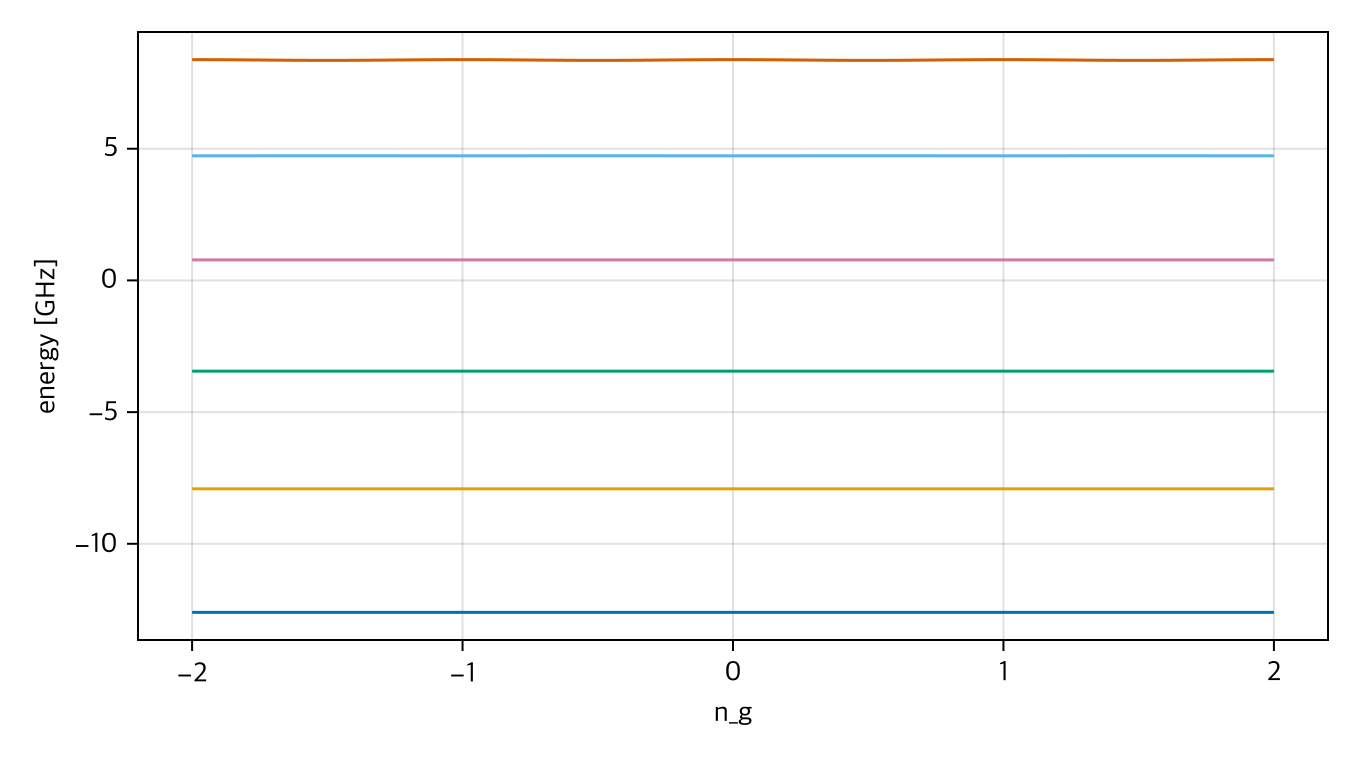

In [9]:
tmon_ng = deepcopy(tmon)
tmon_ng.flux = 0.0
ng_sweep = SingleSystemSweep(tmon_ng, :ng, range(-2.0, 2.0, length=220); evals_count=6)
plot_evals_vs_paramvals_scqubits(ng_sweep; subtract_ground=false, evals_count=6)


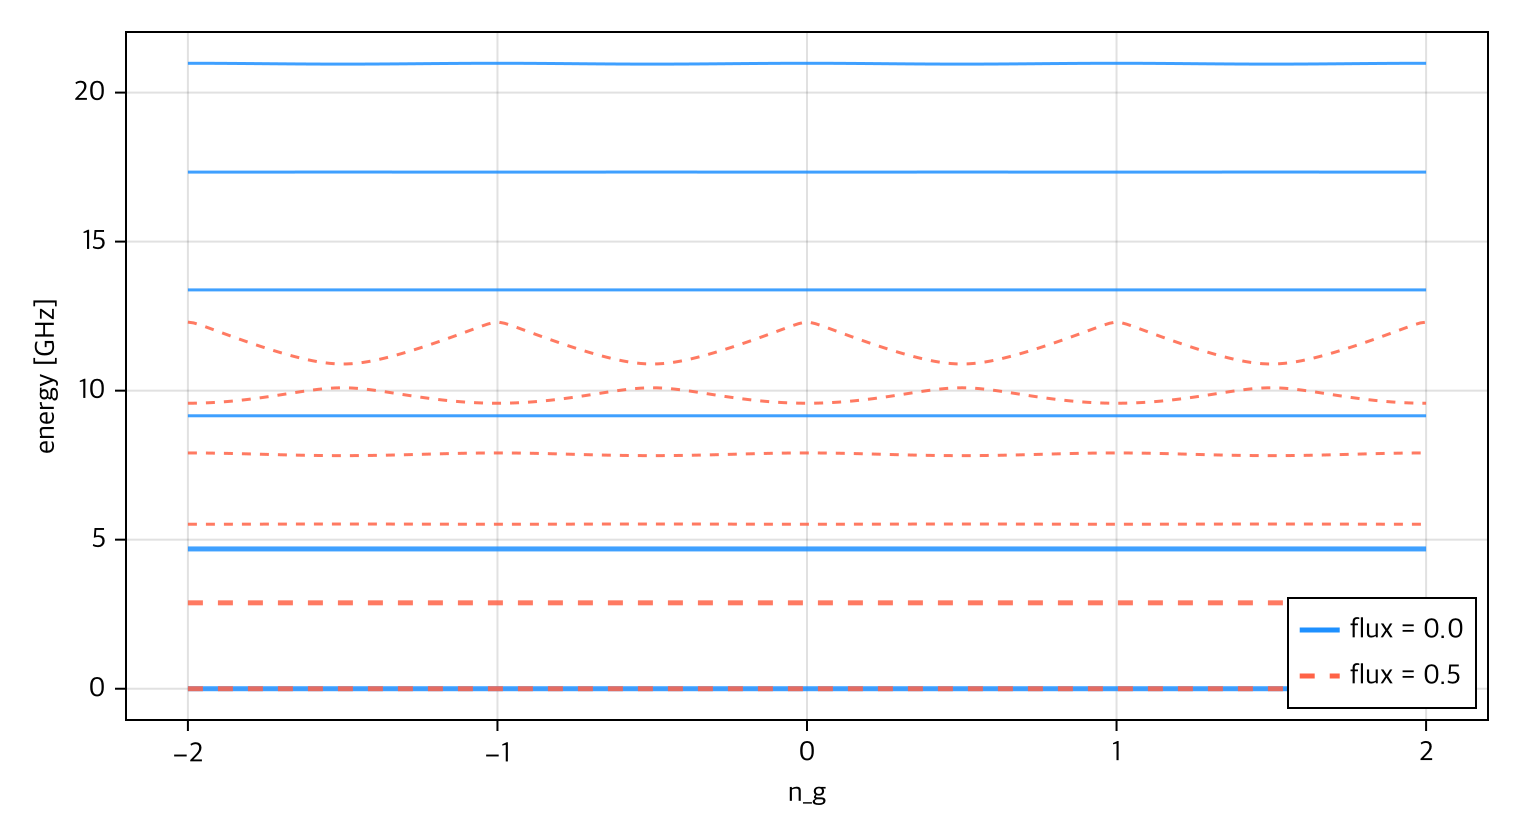

In [10]:
plot_charge_dispersion_overlay([
    ("flux = 0.0", TunableTransmon(EJmax=tmon.EJmax, EC=tmon.EC, d=tmon.d, flux=0.0, ng=0.0, ncut=tmon.ncut, truncated_dim=6), :solid),
    ("flux = 0.5", TunableTransmon(EJmax=tmon.EJmax, EC=tmon.EC, d=tmon.d, flux=0.5, ng=0.0, ncut=tmon.ncut, truncated_dim=6), :dash),
]; ng_vals=range(-2.0, 2.0, length=220), evals_count=6)


In [11]:
for flux in [0.0, 0.5]
    tmon_disp = TunableTransmon(EJmax=tmon.EJmax, EC=tmon.EC, d=tmon.d, flux=flux, ng=0.0, ncut=tmon.ncut, truncated_dim=6)
    spec = get_spectrum_vs_paramvals(tmon_disp, :ng, collect(range(0.0, 0.5, length=101)); evals_count=2)
    w01 = spec.eigenvalues[:, 2] .- spec.eigenvalues[:, 1]
    println((flux=flux, EJ_eff_GHz=round(ej_effective(tmon_disp), digits=6), charge_dispersion_MHz=round((maximum(w01) - minimum(w01)) * 1000, digits=6)))
end


(flux = 0.0, EJ_eff_GHz = 15.0, charge_dispersion_MHz = 0.000152)
(flux = 0.5, EJ_eff_GHz = 6.0, charge_dispersion_MHz = 0.358519)


## 6. Charge-basis and phase-basis wavefunctions

We reuse the same notebook-local helpers introduced in `demo_transmon.ipynb`. The representative operating point here is `flux = 0.0`, and the phase-basis plots include the corresponding cosine potential $-E_{J,\mathrm{eff}}(\Phi) \cos(\phi)$ as a gray reference curve.


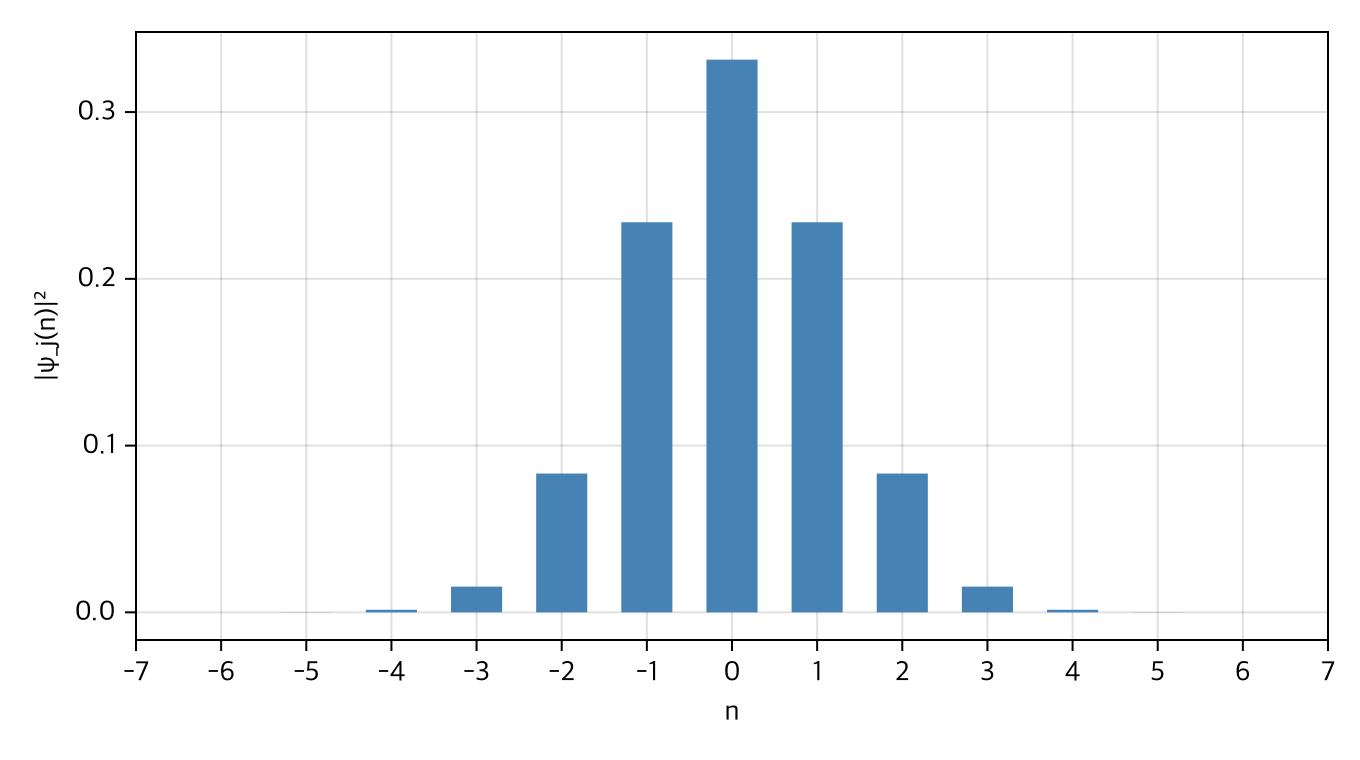

In [12]:
tmon_wf = deepcopy(tmon)
tmon_wf.flux = 0.0
plot_n_wavefunction(tmon_wf; which=0, mode=:abs_sqr, nrange=(-7,7))


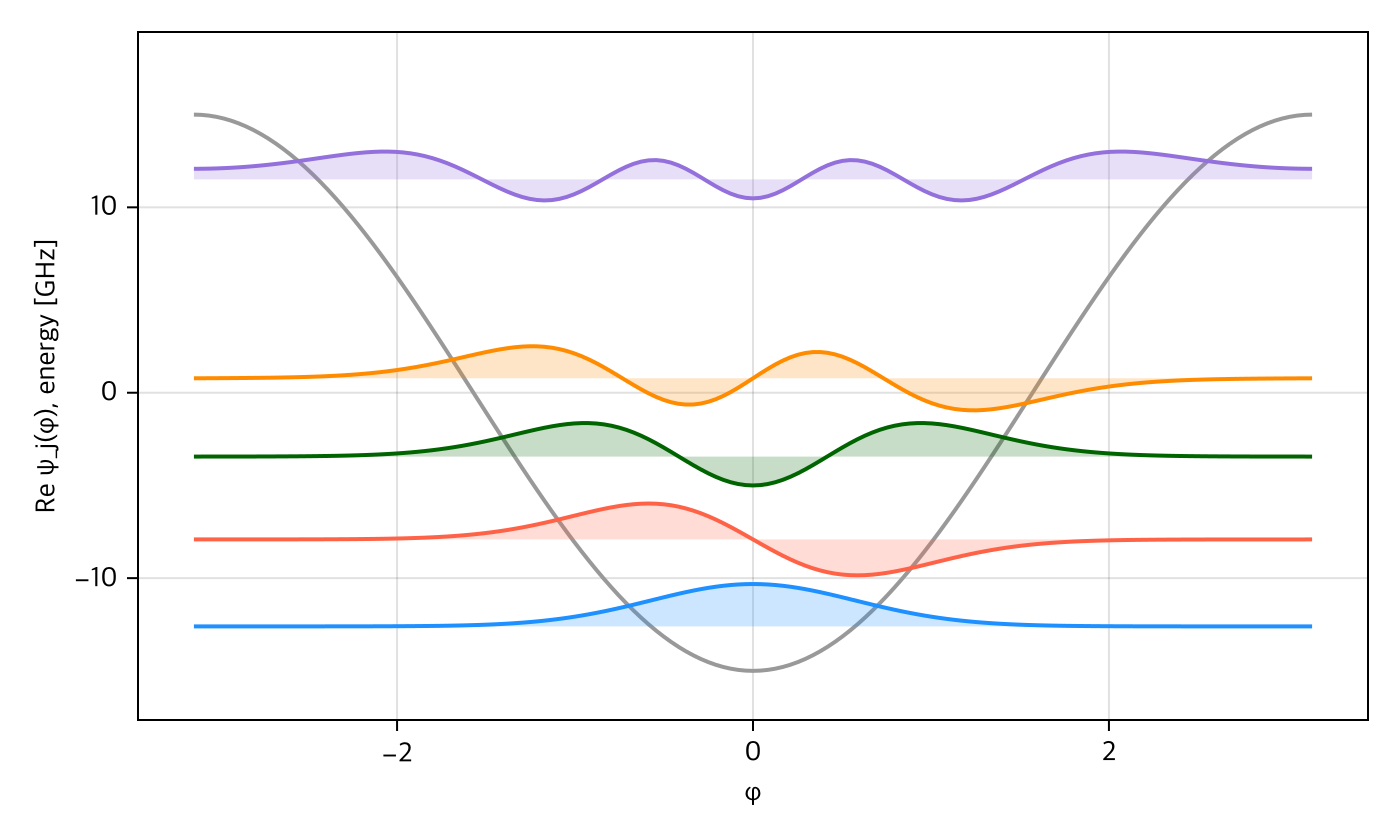

In [13]:
tmon_phi_real = deepcopy(tmon)
tmon_phi_real.flux = 0.0
plot_wavefunction(tmon_phi_real; which=(0, 1, 2, 3, 6), mode=:real)


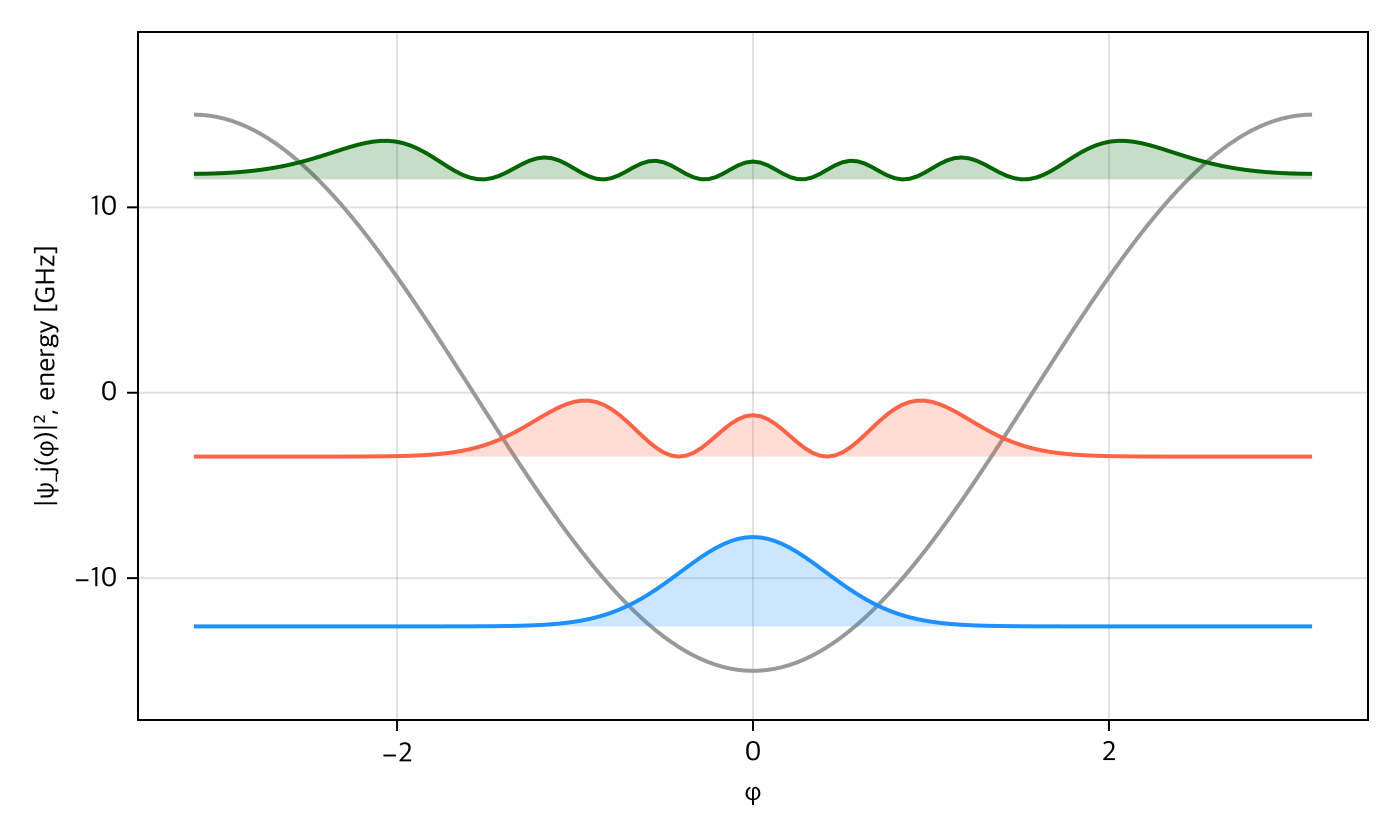

In [14]:
tmon_phi_abs = deepcopy(tmon)
tmon_phi_abs.flux = 0.0
plot_phi_wavefunction(tmon_phi_abs; which=(0, 2, 6), mode=:abs_sqr)


## 7. Matrix elements

We first inspect fixed-flux matrix element tables and heatmaps, then sweep `flux` to see how selected TunableTransmon matrix elements evolve across the SQUID tuning curve.


In [15]:
tmon_mel = deepcopy(tmon)
tmon_mel.flux = 0.0
round.(matrixelement_table(tmon_mel, n_operator(tmon_mel); evals_count=3), digits=6)


3×3 Matrix{ComplexF64}:
     -0.0+0.0im  -1.21043+0.0im     -0.0+0.0im
 -1.21043+0.0im      -0.0+0.0im  1.67018+0.0im
     -0.0+0.0im   1.67018+0.0im      0.0+0.0im

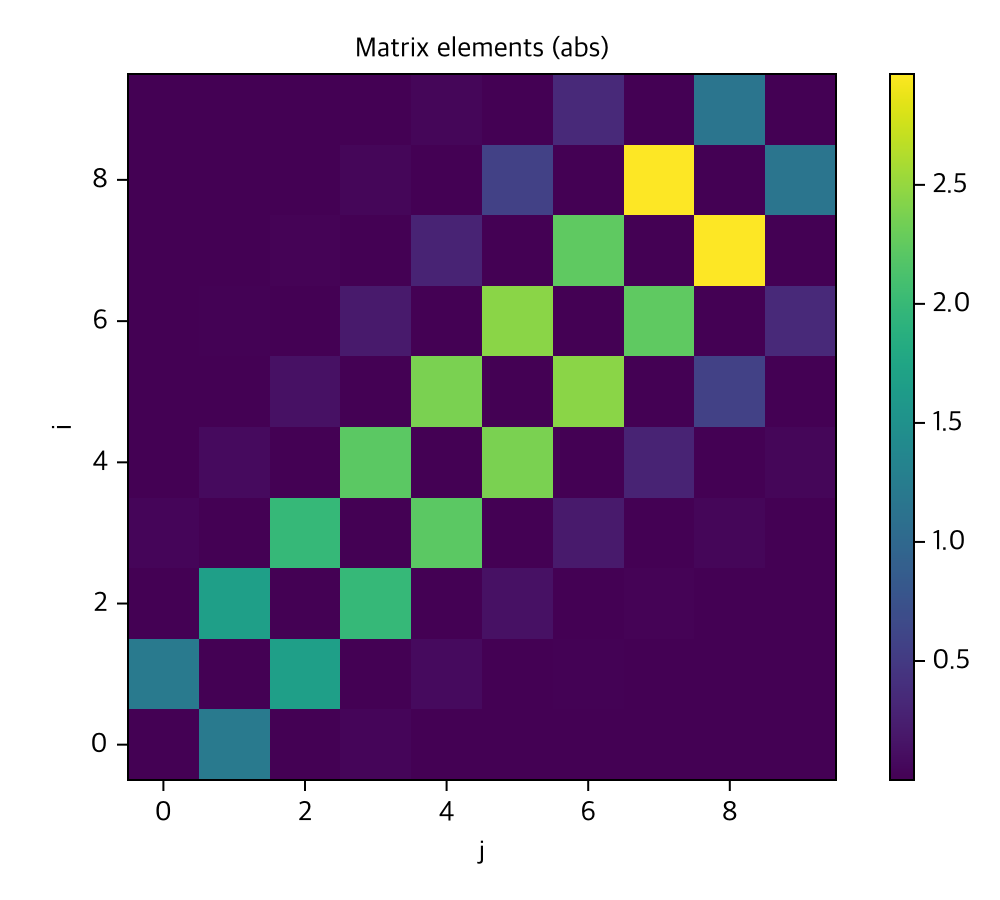

In [16]:
tmon_mel_plot = deepcopy(tmon)
tmon_mel_plot.flux = 0.0
plot_matrixelements(tmon_mel_plot, s -> n_operator(s); evals_count=10, mode=:abs)


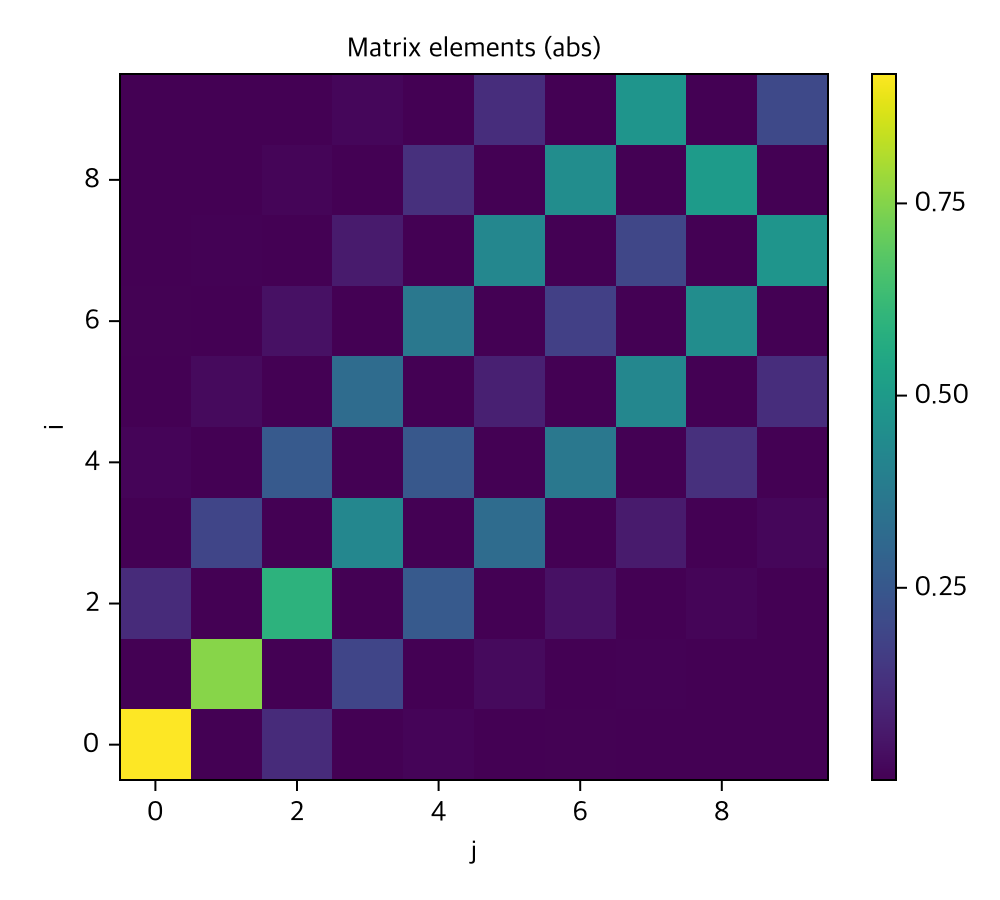

In [17]:
tmon_cos_plot = deepcopy(tmon)
tmon_cos_plot.flux = 0.0
plot_matrixelements(tmon_cos_plot, s -> cos_phi_operator(s); evals_count=10, mode=:abs)


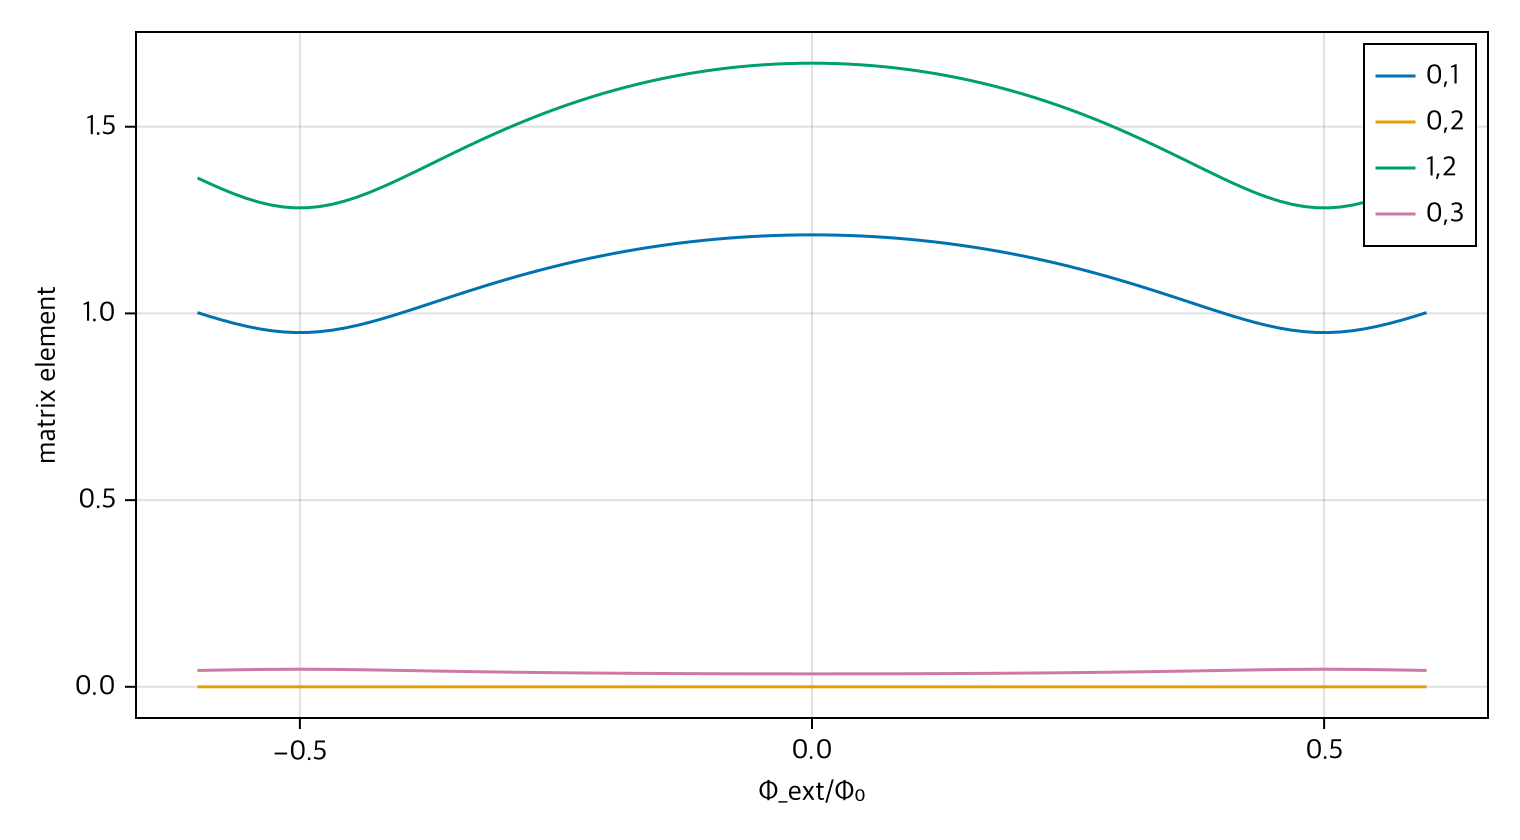

In [18]:
tmon_flux_mel = TunableTransmon(EJmax=tmon.EJmax, EC=tmon.EC, d=tmon.d, flux=0.0, ng=0.0, ncut=tmon.ncut, truncated_dim=8)
plot_matelems_vs_paramvals(
    tmon_flux_mel,
    s -> n_operator(s),
    :flux,
    range(-0.6, 0.6, length=101);
    pairs=[(1, 2), (1, 3), (2, 3), (1, 4)],
    mode=:abs,
)


## 8. Circuit-derived SQUID validation

We build the same SQUID from two parallel JJ branches in `Circuit` and compare the resulting spectrum against `TunableTransmon`.

**Symmetric SQUID example ($d = 0$):**
- JJ1: $E_{J1} = E_{J,\max}/2 = 7.5$ GHz
- JJ2: $E_{J2} = E_{J,\max}/2 = 7.5$ GHz
- Each branch uses $E_{C,\mathrm{branch}} = 0.1$ GHz, which gives $E_{C,\mathrm{total}} = 0.2$ GHz when the two branches are in parallel

**Asymmetric SQUID example used in this notebook ($d = 0.4$):**
- JJ1: $E_{J1} = E_{J,\max}(1-d)/2 = 4.5$ GHz
- JJ2: $E_{J2} = E_{J,\max}(1+d)/2 = 10.5$ GHz
- With the same $E_{C,\mathrm{branch}} = 0.1$ GHz on each branch, the total charging energy is again $E_{C,\mathrm{total}} = 0.2$ GHz

The `EC` passed to `TunableTransmon(EJmax, EC, d, ...)` is the total/effective charging energy entering the Hamiltonian term $4E_C(n-n_g)^2$, not a per-junction branch charging energy.


In [19]:
# For two identical JJ branches in parallel, EC_branch = 0.1 gives EC_total = 0.2.
desc = """
branches:
  - [JJ, 0, 1, EJ=4.5, EC=0.1]
  - [JJ, 0, 1, EJ=10.5, EC=0.1]
"""
circ = Circuit(desc; ncut=30)
println("Number of external flux values: $(length(circ.external_flux_values))")

println("\nComparison for flux dependence of Effective and Circuit (asymmetric SQUID):")
println("  Φ/Φ₀     TunableTransmon ω₀₁    Circuit ω₀₁")
println("  " * "-"^50)
for flux in [0.0, 0.125, 0.25, 0.375]
    tt = TunableTransmon(EJmax=15.0, EC=0.2, d=0.4, flux=flux, ncut=30, truncated_dim=3)
    e_tt = eigenvals(tt; evals_count=3)

    set_external_flux!(circ, 1, 2π * flux)
    e_circ = eigenvals(circ; evals_count=3)

    w01_tt = e_tt[2] - e_tt[1]
    w01_circ = e_circ[2] - e_circ[1]
    println("  $(round(flux, digits=3))     $(round(w01_tt, digits=4))              $(round(w01_circ, digits=4))")
end

Number of external flux values: 1

Comparison for flux dependence of Effective and Circuit (asymmetric SQUID):
  Φ/Φ₀     TunableTransmon ω₀₁    Circuit ω₀₁
  --------------------------------------------------
  0.0     4.6898              4.6898
  0.125     4.5313              4.5313
  0.25     4.0645              4.0645
  0.375     3.3599              3.3599


In [20]:
circ.var_categories

VarCategories(periodic=[1], extended=Int64[], free=Int64[], frozen=Int64[])